### Tahap 1 — Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import joblib

import warnings
warnings.filterwarnings('ignore')

### Tahap 2 — Load Dataset

In [2]:
df = pd.read_csv("../data/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Tahap 3 — Informasi Dataset

In [3]:
df.info()
df.shape
df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


np.int64(418)

### Tahap 4 — Hapus Duplikasi

In [4]:
df.drop_duplicates(inplace=True)

df.shape

(49582, 2)

### Tahap 5 — Distribusi Sentimen

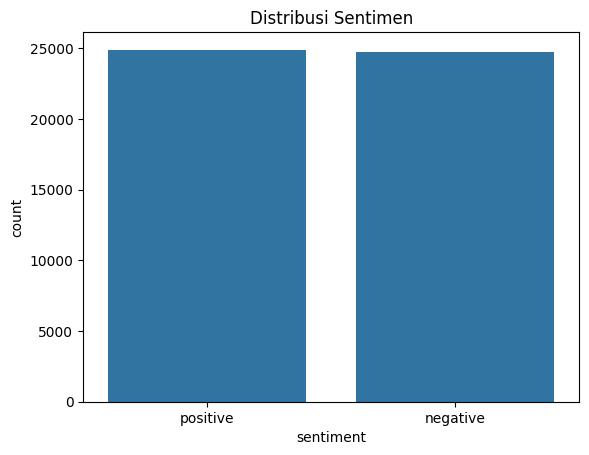

In [5]:
df['sentiment'].value_counts()

sns.countplot(
    x='sentiment',
    data=df
)

plt.title("Distribusi Sentimen")
plt.show()

### Tahap 6 — Panjang Review

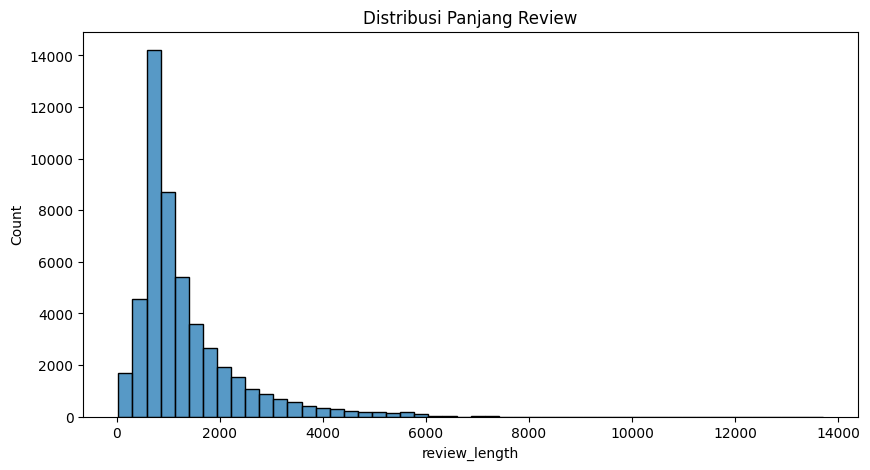

In [6]:
df['review_length'] = df['review'].apply(len)

df['review_length'].describe()

plt.figure(figsize=(10,5))

sns.histplot(
    df['review_length'],
    bins=50
)

plt.title("Distribusi Panjang Review")
plt.show()

### Tahap 7 — Text Cleaning

#### Lowercase

In [7]:
def clean_text(text):

    text = text.lower()

    return text

#### Remove HTML

In [8]:
def remove_html(text):

    clean = re.compile('<.*?>')

    return re.sub(clean, '', text)

#### Remove URL

In [9]:
def remove_url(text):

    return re.sub(
        r'https?://\S+|www\.\S+',
        '',
        text
    )

#### Remove Punctuation

In [10]:
def remove_punctuation(text):

    return text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

#### Gabungkan Semua

In [11]:
def preprocessing(text):

    text = clean_text(text)

    text = remove_html(text)

    text = remove_url(text)

    text = remove_punctuation(text)

    return text

df['clean_review'] = df['review'].apply(preprocessing)

In [12]:
positive_text = " ".join(
    df[df['sentiment'] == 'positive']['clean_review']
)

negative_text = " ".join(
    df[df['sentiment'] == 'negative']['clean_review']
)

print("Positive text:", len(positive_text))
print("Negative text:", len(negative_text))

Positive text: 31447807
Negative text: 30365943


### Tahap 8 — Word Cloud Positif

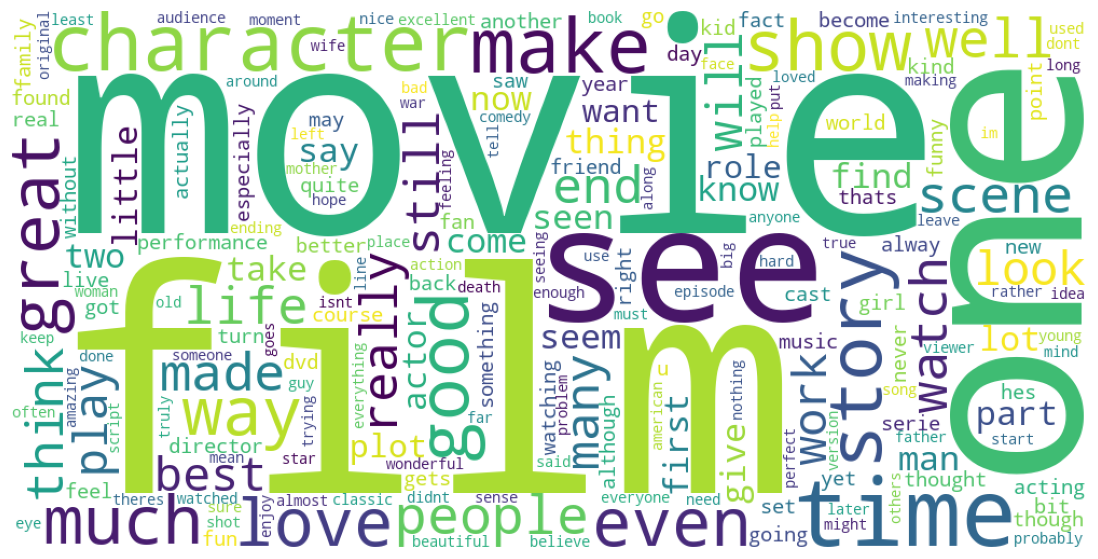

In [13]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

wordcloud.to_file(
    "../results/wordcloud_positive.png"
)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Tahap 9 — Word Cloud Negatif

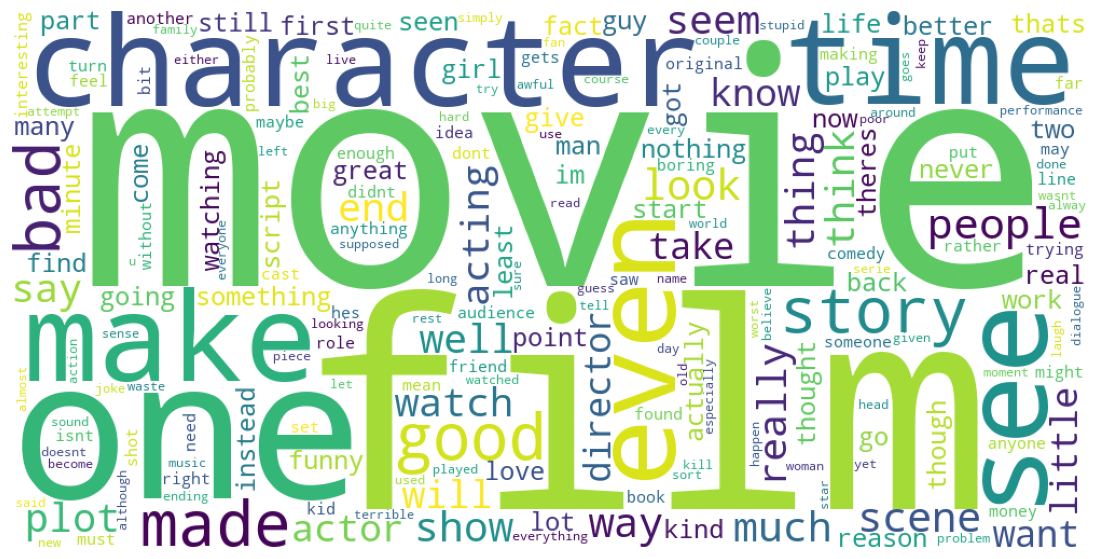

In [14]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

wordcloud.to_file(
    "../results/wordcloud_negative.png"
)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Tahap 10 — Encoding Label

In [15]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

### Tahap 11 — Train Test Split

In [16]:
X = df['clean_review']

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Tahap 12 — TF-IDF

In [17]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

### Tahap 13 — Model 1 Logistic Regression

In [18]:
lr = LogisticRegression()

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



### Tahap 14 — Model 2 SVM

In [19]:
svm = LinearSVC()
svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4940
           1       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



### Tahap 15 — Model 3 Naive Bayes


In [20]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

print(
    classification_report(
        y_test,
        nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      4940
           1       0.86      0.85      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



### Tahap 16 — Perbandingan Akurasi

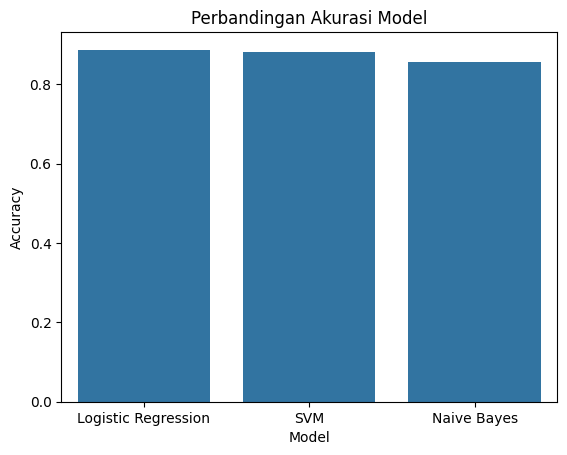

In [21]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'SVM',
        'Naive Bayes'
    ],
    'Accuracy':[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,svm_pred),
        accuracy_score(y_test,nb_pred)
    ]
})

results

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title(
    "Perbandingan Akurasi Model"
)

plt.savefig(
    "../results/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

### Tahap 17 — Confusion Matrix SVM

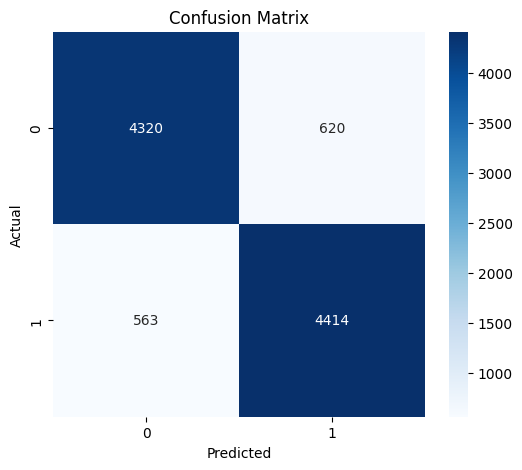

In [22]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Tahap 18 — ROC Curve

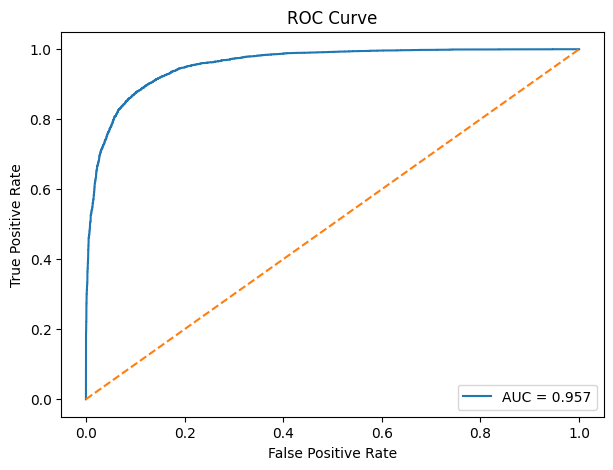

In [23]:
y_prob = lr.predict_proba(
    X_test_tfidf
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "../results/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

### Tahap 19 — Prediksi Review Baru

In [24]:
review = """
This movie was absolutely amazing.
The acting was fantastic.
"""

review = preprocessing(review)

review_vec = tfidf.transform([review])

prediction = svm.predict(review_vec)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


### Tahap 20 — Simpan Model

In [25]:
joblib.dump(
    svm,
    "../models/svm_model.pkl"
)

joblib.dump(
    lr,
    "../models/lr_model.pkl"
)

joblib.dump(
    nb,
    "../models/nb_model.pkl"
)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

### Tahap 21 — Load Model

In [26]:
model = joblib.load(
    "../models/svm_model.pkl"
)

vectorizer = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

### Tahap 22 — Kesimpulan

# Kesimpulan

1. Dataset IMDb berhasil diproses menggunakan TF-IDF.
2. Dilakukan perbandingan Logistic Regression, SVM, dan Naive Bayes.
3. SVM menghasilkan performa terbaik dengan akurasi sekitar 90%.
4. Model berhasil disimpan menggunakan Joblib.
5. Model dapat digunakan untuk memprediksi sentimen review film baru.

# Akurasi Setiap Model

In [27]:
print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("SVM:",
      accuracy_score(y_test, svm_pred))

print("Naive Bayes:",
      accuracy_score(y_test, nb_pred))

Logistic Regression: 0.8868609458505596
SVM: 0.880709892104467
Naive Bayes: 0.8552989815468388


# Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    svm,
    X_train_tfidf,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.87734779 0.87633934 0.88440691 0.87835623 0.8753309 ]
0.8783562334551872


# Top Words Positif & Negatif

In [29]:
feature_names = tfidf.get_feature_names_out()

coef = svm.coef_[0]

top_positive = np.argsort(coef)[-20:]

top_negative = np.argsort(coef)[:20]

# Hyperparameter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV

params = {
    'C':[0.1,1,10]
}

grid = GridSearchCV(
    LinearSVC(),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(
    X_train_tfidf,
    y_train
)

print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.8877347787722174


In [31]:
import os

print(os.listdir("results"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'results'